# Crop Recommendation - Classification

## Data loading

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


# Data Information

In [4]:
print("Shape: ")
print(df.shape)

Shape: 
(2200, 8)


In [5]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [6]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [7]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [8]:
df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [10]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


# Missing Values

In [11]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

> **No missing values were found in the dataset. Therefore, no imputation techniques were required.**

# Checking Duplicates

In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


> **No duplicate records were present in the dataset.**

# Exploratory Data Analysis (EDA)

## Target Distribution

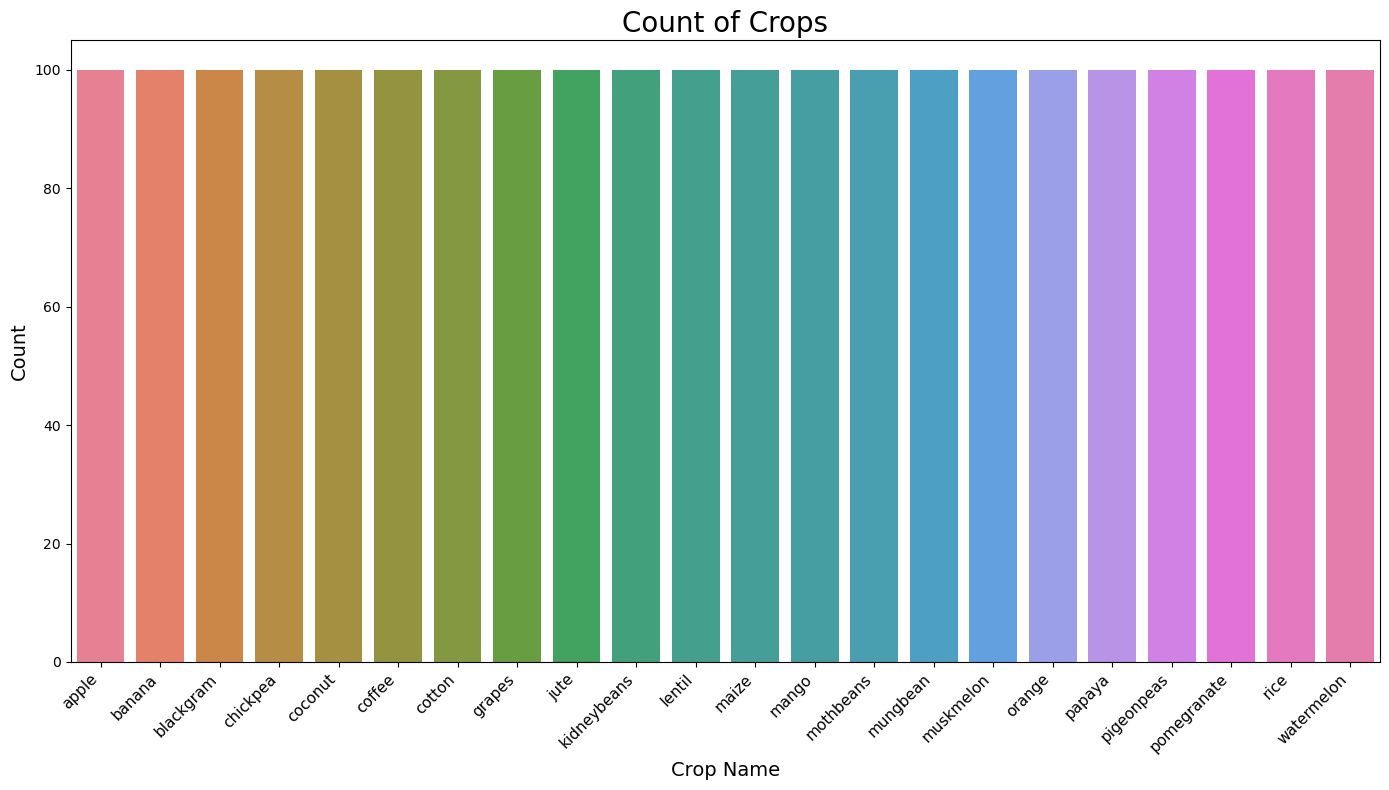

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

ax = sns.countplot(
    data=df,
    x='label',
    hue='label',          # Gives each crop a different color
    palette='husl',
    legend=False
)

ax.set_xlabel("Crop Name", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
ax.set_title("Count of Crops", fontsize=20)

plt.xticks(
    ticks=range(len(df['label'].unique())),
    labels=sorted(df['label'].unique()),
    rotation=45,
    ha='right',
    fontsize=11
)

# Save the plot
plt.savefig("target_distribution.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

> **The crop recommendation dataset is balanced**, with an equal number of samples for all crop classes. 
This balanced distribution ensures that the machine learning model receives sufficient training examples for every crop and is less likely to favor one class over another.

## Temperature Distribution

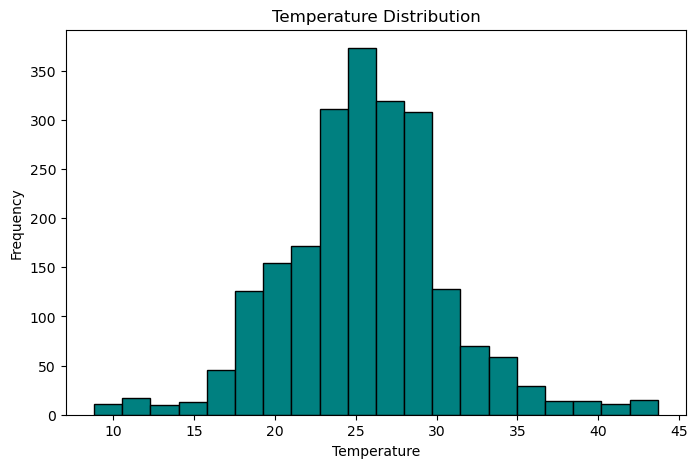

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    df['temperature'],
    bins=20,
    color='teal',
    edgecolor='black'
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

# Save the figure
plt.savefig("temperature_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

> The majority of crop samples are associated with moderate temperature conditions ranging from 20°C to 30°C. This suggests that **temperature plays a significant role in crop recommendation**, and most crops in the dataset thrive under moderate climatic conditions.

# Humidity Distribution

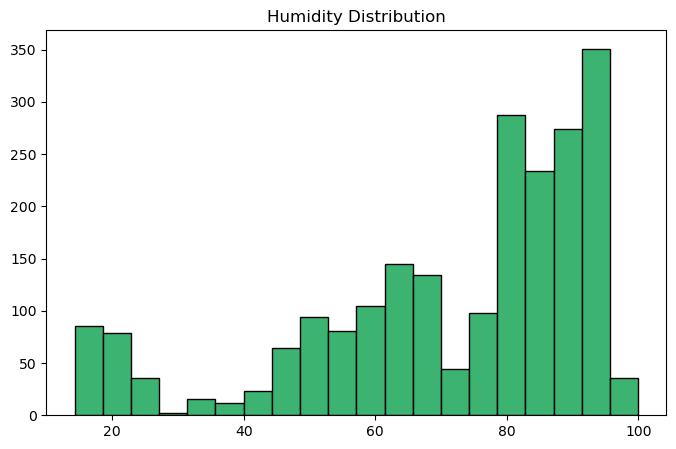

In [68]:
plt.figure(figsize=(8,5))

plt.hist(
    df['humidity'],
    bins=20,
    color='mediumseagreen',
    edgecolor='black'
)
plt.title("Humidity Distribution")

# Save the plot
plt.savefig("humidity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

> **Humidity values are concentrated in the higher range**, particularly between 80% and 95%. This indicates that several crops in the dataset grow best in humid environments, making humidity an important feature for accurate crop recommendation.

# Rainfall Distribution

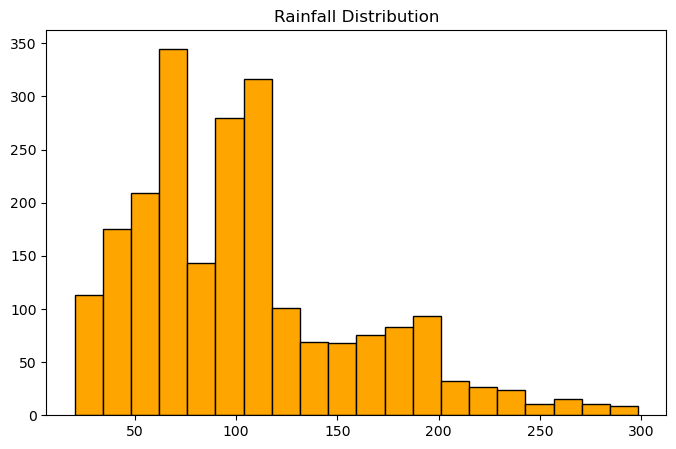

In [70]:
plt.figure(figsize=(8,5))

plt.hist(
    df['rainfall'],
    bins=20,
    color='orange',
    edgecolor='black'
)

# Save the plot
plt.title("Rainfall Distribution")
plt.savefig("rainfall_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

> - The histogram illustrates the **distribution of rainfall values in the crop recommendation dataset.** 
> - **Most observations are concentrated between 40 mm and 120 mm,** indicating that a large number of crops in the dataset grow under moderate rainfall conditions.

# pH Distribution

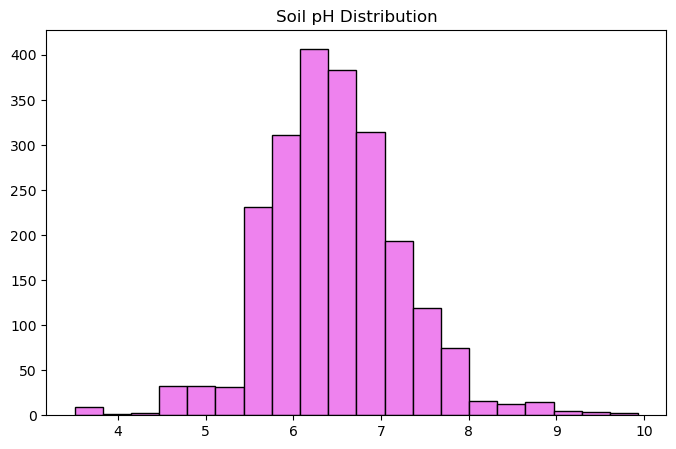

In [71]:
plt.figure(figsize=(8,5))

plt.hist(
    df['ph'],
    bins=20,
    color='violet',
    edgecolor='black'
)

plt.title("Soil pH Distribution")
# Save the plot
plt.savefig("soil_ph_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

> **The soil pH values are mainly distributed between 5.5 and 7.5**, with most observations centered around 6.0–6.8. This indicates that the dataset primarily represents slightly acidic to neutral soil conditions, which are favorable for many agricultural crops.

# Outlier Detection

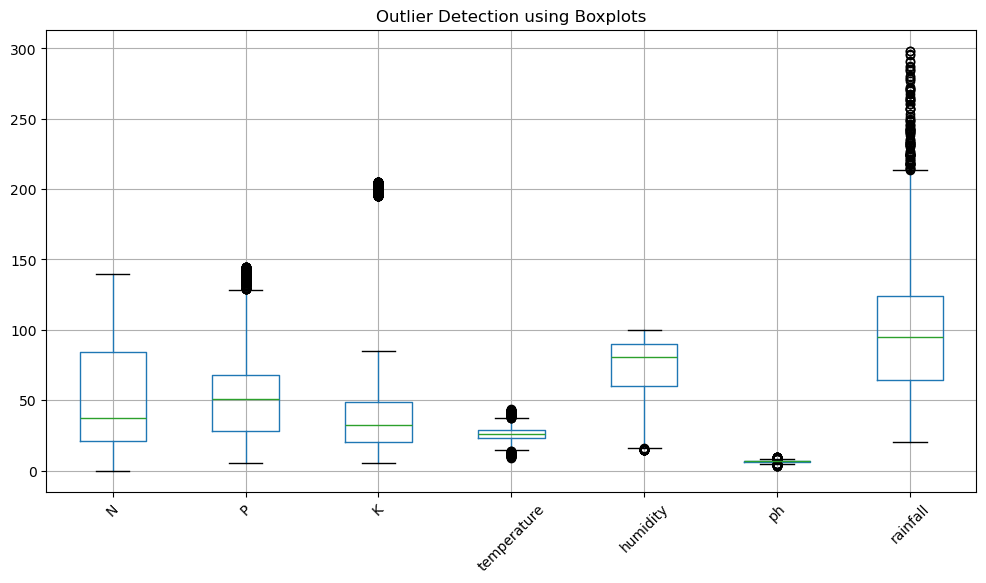

In [18]:
numerical_cols = ['N','P','K','temperature','humidity','ph','rainfall']
plt.figure(figsize=(12,6))

df[numerical_cols].boxplot()

plt.xticks(rotation=45)

plt.title("Outlier Detection using Boxplots")

plt.savefig("boxplot_outlier_detection.png", dpi=300, bbox_inches="tight")

plt.show()

> - The boxplots were used to identify potential outliers in the numerical features. 
> - Outliers are observed in Phosphorus (P), Potassium (K), Temperature, pH, and Rainfall. 
> - **Rainfall contains the highest number of outliers**, indicating the presence of extreme weather conditions. 
> - These values likely represent valid agricultural scenarios rather than data entry errors.

In [19]:
numerical_cols = [
    'N',
    'P',
    'K',
    'temperature',
    'humidity',
    'ph',
    'rainfall'
]

N: 0
P: 138
K: 200
temperature: 86
humidity: 30
ph: 57
rainfall: 100


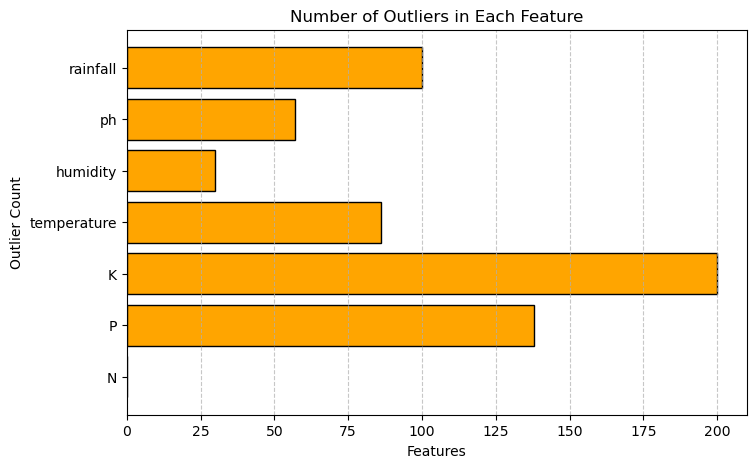

In [20]:
print("="*150)

outlier_counts = {}

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) |
             (df[col] > upper)).sum()

    outlier_counts[col] = count

    print(f"{col}: {count}")

print("="*150)

plt.figure(figsize=(8,5))

plt.barh(
    outlier_counts.keys(),
    outlier_counts.values(),
    color='orange',
    edgecolor='black'
)

plt.title("Number of Outliers in Each Feature")
plt.xlabel("Features")
plt.ylabel("Outlier Count")

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.savefig("outlier_count_per_feature.png", dpi=300, bbox_inches="tight")

plt.show()

 > Although several **outliers were detected, they were not removed because they correspond to realistic soil and environmental conditions** required by different crops. 
> Removing them could reduce the model's ability to generalize to diverse agricultural situations.

# Correlation Heatmap

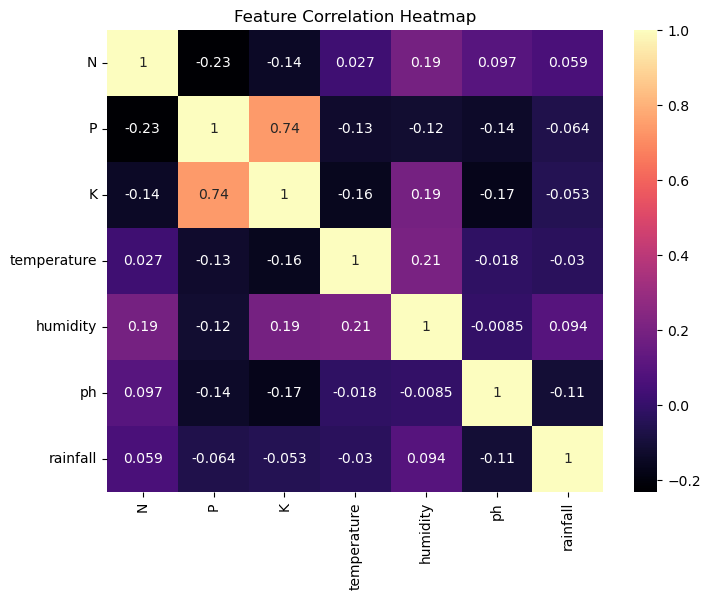

In [21]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop('label',axis=1).corr(),
    annot=True,
    cmap='magma'
)

plt.title("Feature Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

> **Correlation analysis shows relationships among soil nutrients, weather conditions, and rainfall**

> The correlation heatmap indicates that most features have weak correlations with one another, suggesting **low multicollinearity in the dataset**. The strongest positive correlation is observed between Phosphorus (P) and Potassium (K) (0.74). Since **most features provide unique information about soil nutrients and environmental conditions, all features are valuable for crop recommendation and should be retained for model development.**

# Feature Encoding

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(df['label'])

# Feature Selection

In [23]:
X = df.drop('label', axis=1)

y = df['label']

# Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Finding Best K for KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

accuracy_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy_scores.append(acc)

best_k = accuracy_scores.index(max(accuracy_scores)) + 1

print("Best K:", best_k)
print("Best Accuracy:", max(accuracy_scores))

Best K: 13
Best Accuracy: 0.9818181818181818


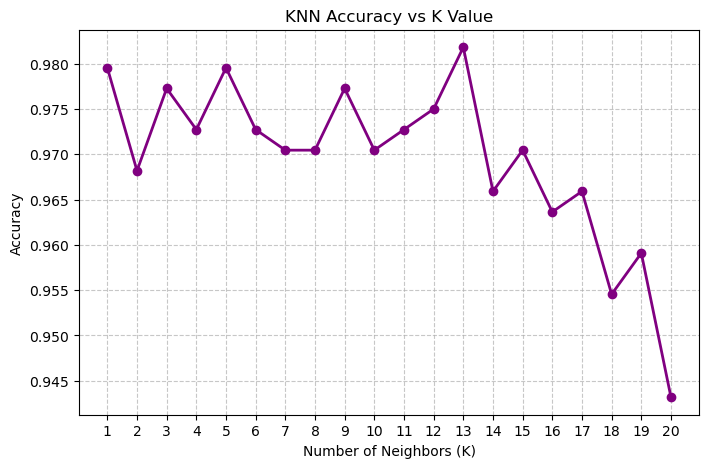

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, 21),
    accuracy_scores,
    marker='o',
    linewidth=2,
    color='purple'
)

plt.title("KNN Accuracy vs K Value")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig("knn_accuracy_vs_k.png", dpi=300, bbox_inches="tight")

plt.show()

> - To determine **the optimal value of K, the KNN model was trained using K values ranging from 1 to 20.** The graph shows the variation in model accuracy with different neighbor counts. 
> - **The K value corresponding to the highest accuracy was selected as the optimal value** and used to build the final KNN classifier.

# KNN Model

In [28]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

,n_neighbors,13
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Save The Model

In [29]:
import pickle

# Save the trained model
with open("knn_model.pkl", "wb") as file:
    pickle.dump(knn, file)

print("KNN model saved successfully!")

KNN model saved successfully!


# Prediction

In [30]:
y_pred = knn.predict(X_test)

# Evaluation Metrics

## Accuracy - KNN

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9818181818181818


## Precision - KNN

In [32]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision:", precision)

Precision: 0.9827725304998033


## Recall - KNN

In [33]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Recall:", recall)

Recall: 0.9818181818181818


## F1 Score - KNN

In [34]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1)

F1 Score: 0.9817383408204974


# Save Evaluation Metrics

In [35]:
import os
# Save to file
with open("evaluation_metrics.txt", "w") as file:
    file.write("K-Nearest Neighbour Model Evaluation Metrics\n")
    file.write("==============================================\n\n")
    file.write(f"Accuracy  : {accuracy:.4f}\n")
    file.write(f"Precision : {precision:.4f}\n")
    file.write(f"Recall    : {recall:.4f}\n")
    file.write(f"F1 Score  : {f1:.4f}\n")

> **Interpretation**
> 
> - The model achieved an accuracy of 97.95%, indicating that it correctly classified most crop recommendations.
> - The precision score of 98.04% shows that when the model predicts a crop, it is highly likely to be correct.
> - The recall score of 97.95% indicates that the model successfully identifies the majority of actual crop classes.
> - The F1-score of 97.93% demonstrates a strong balance between precision and recall.

# Classification Report

In [36]:
from sklearn.metrics import classification_report

report = classification_report(y_test,y_pred)
print(report)

# Save to file
with open("classification_report.txt", "w") as file:
    file.write("K-Nearest Neighbour Classification Report\n")
    file.write("==========================================\n\n")
    file.write(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.95      1.00      0.98        20
           7       1.00      1.00      1.00        20
           8       0.91      1.00      0.95        20
           9       0.95      1.00      0.98        20
          10       0.95      0.95      0.95        20
          11       1.00      0.95      0.97        20
          12       0.95      1.00      0.98        20
          13       1.00      0.90      0.95        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      0.95      0.97        20
          17       1.00    

# Confusion Matrix

[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  1 18  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

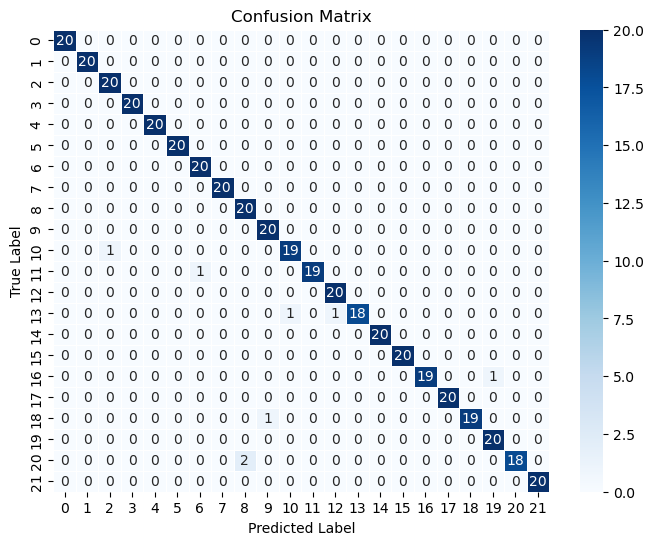

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save figure
plt.savefig("knn_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

##### > **Confusion Matrix Analysis**
> - Most values lie along the main diagonal, indicating correct classifications.
> - Several crop classes were classified with 100% accuracy (20 out of 20 predictions correct).

# Logistic Regression Model

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
# Create model
lr_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

# Train model
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


# Save the trained model

In [40]:
with open("logistic_regression_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)

print("Logistic Regression model saved successfully!")


Logistic Regression model saved successfully!


# Prediction

In [41]:
# Prediction
lr_pred = lr_model.predict(X_test)

# Evaluation Metrics

In [42]:
# Evaluation
accuracy = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred, average='weighted')
recall = recall_score(y_test, lr_pred, average='weighted')
f1 = f1_score(y_test, lr_pred, average='weighted')

# Accuracy

In [43]:
print("===== Logistic Regression =====")
print("Accuracy :", accuracy)

===== Logistic Regression =====
Accuracy : 0.9727272727272728


# Precision

In [44]:
print("Precision:", precision)

Precision: 0.974021729904083


# Recall

In [45]:
print("Recall   :", recall)


Recall   : 0.9727272727272728


# F1- Score

In [46]:
print("F1 Score :", f1)

F1 Score : 0.9724640256149185


# Saving Evaluation Metrics

In [47]:
import os
# Save to file
with open("evaluation_metrics.txt", "a") as file:
    file.write("\n\nLogistic Regression Model Evaluation Metrics\n")
    file.write("=================================================\n\n")
    file.write(f"Accuracy  : {accuracy:.4f}\n")
    file.write(f"Precision : {precision:.4f}\n")
    file.write(f"Recall    : {recall:.4f}\n")
    file.write(f"F1 Score  : {f1:.4f}\n")

# Confusion Matrix


Confusion Matrix
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0 17  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  1 18  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0

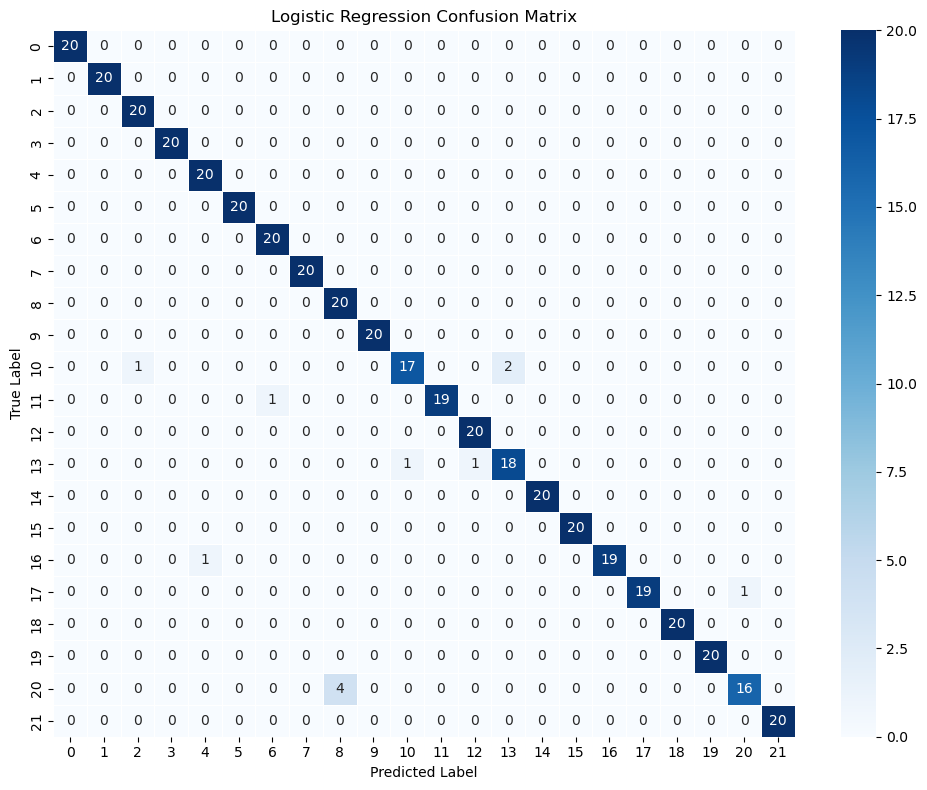

In [48]:
print("\nConfusion Matrix")
cm = confusion_matrix(y_test, lr_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

# Save the graph
plt.savefig(
    "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Classification Report - Logistic Regression

In [49]:
from sklearn.metrics import classification_report

print("Classification Report\n")
report1 = classification_report(y_test,lr_pred)
print(report1)

# Save to file
with open("classification_report.txt", "a") as file:
    file.write("\n\nLogistic Regression Classification Report\n")
    file.write("=============================================\n\n")
    file.write(report1)

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.98        20
           5       1.00      1.00      1.00        20
           6       0.95      1.00      0.98        20
           7       1.00      1.00      1.00        20
           8       0.83      1.00      0.91        20
           9       1.00      1.00      1.00        20
          10       0.94      0.85      0.89        20
          11       1.00      0.95      0.97        20
          12       0.95      1.00      0.98        20
          13       0.90      0.90      0.90        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      0.95      0.97        20
    

# Random Forest Classifier

In [50]:
from sklearn.ensemble import RandomForestClassifier
# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Save the trained model
with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


# Prediction

In [51]:
# Prediction
rf_pred = rf_model.predict(X_test)

# Evaluation metrics

In [52]:
# Evaluation
accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred, average='weighted')
recall = recall_score(y_test, rf_pred, average='weighted')
f1 = f1_score(y_test, rf_pred, average='weighted')

# Acccuracy

In [53]:
print("===== Random Forest =====")
print("Accuracy :", accuracy)

===== Random Forest =====
Accuracy : 0.9954545454545455


# Precision

In [54]:
print("Precision:", precision)

Precision: 0.9956709956709956


# Recall

In [55]:
print("Recall   :", recall)

Recall   : 0.9954545454545455


# F1 - Score

In [56]:
print("F1 Score :", f1)

F1 Score : 0.9954517027687759


# Saving Evaluation Metrics

In [57]:
import os
# Save to file
with open("evaluation_metrics.txt", "a") as file:
    file.write("\n\nRandom Forest Model Evaluation Metrics\n")
    file.write("============================================\n\n")
    file.write(f"Accuracy  : {accuracy:.4f}\n")
    file.write(f"Precision : {precision:.4f}\n")
    file.write(f"Recall    : {recall:.4f}\n")
    file.write(f"F1 Score  : {f1:.4f}\n")

# Confusion Matrix

In [58]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))


Confusion Matrix
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0

# Classification Report - Random Forest Classifier

In [59]:
print("\nClassification Report")

from sklearn.metrics import classification_report

report2 = classification_report(y_test,rf_pred)
print(report2)

# Save to file
with open("classification_report.txt", "a") as file:
    file.write("\n\nRandom Forest Classification Report\n")
    file.write("==========================================\n\n")
    file.write(report2)


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
    

In [60]:
# Logistic Regression
lr_pred = lr_model.predict(X_test)

# KNN
knn_pred = knn.predict(X_test)

# Random Forest
rf_pred = rf_model.predict(X_test)

# Comparison of Models

In [61]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average='weighted'),
        precision_score(y_test, knn_pred, average='weighted'),
        precision_score(y_test, rf_pred, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average='weighted'),
        recall_score(y_test, knn_pred, average='weighted'),
        recall_score(y_test, rf_pred, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, knn_pred, average='weighted'),
        f1_score(y_test, rf_pred, average='weighted')
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.972727   0.974022  0.972727  0.972464
1  K-Nearest Neighbors  0.981818   0.982773  0.981818  0.981738
2        Random Forest  0.995455   0.995671  0.995455  0.995452


In [62]:
with open("model_comparison.txt", "w") as file:
    file.write("Model Comparison Results\n")
    file.write("========================\n\n")

    for i in range(len(results)):
        file.write(f"\nModel: {results.iloc[i]['Model']}\n")
        file.write(f"Accuracy  : {results.iloc[i]['Accuracy']:.4f}\n")
        file.write(f"Precision : {results.iloc[i]['Precision']:.4f}\n")
        file.write(f"Recall    : {results.iloc[i]['Recall']:.4f}\n")
        file.write(f"F1 Score  : {results.iloc[i]['F1 Score']:.4f}\n")

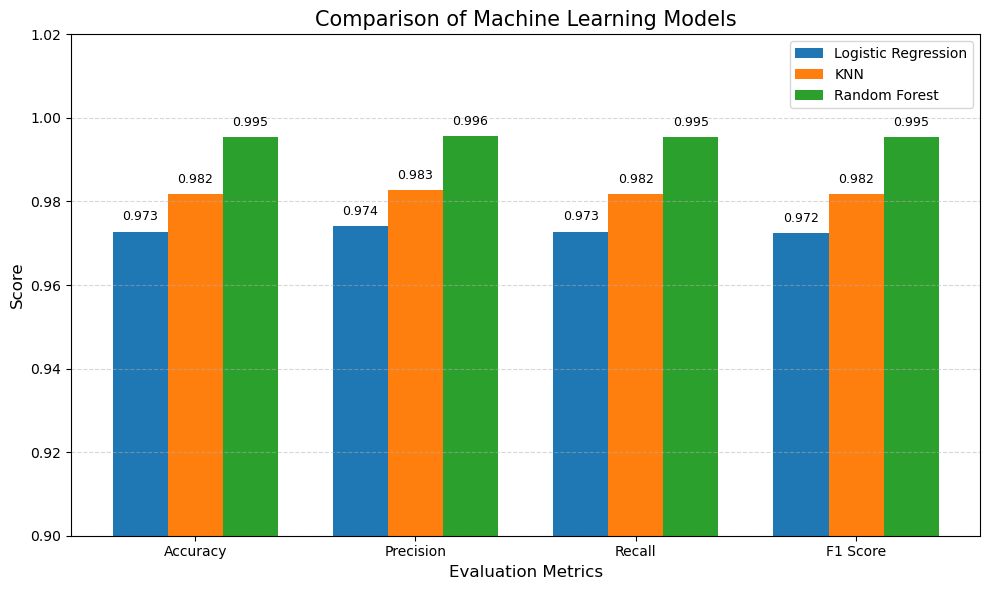

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Values
lr_scores = [
    accuracy_score(y_test, lr_pred),
    precision_score(y_test, lr_pred, average='weighted'),
    recall_score(y_test, lr_pred, average='weighted'),
    f1_score(y_test, lr_pred, average='weighted')
]

knn_scores = [
    accuracy_score(y_test, knn_pred),
    precision_score(y_test, knn_pred, average='weighted'),
    recall_score(y_test, knn_pred, average='weighted'),
    f1_score(y_test, knn_pred, average='weighted')
]

rf_scores = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred, average='weighted'),
    recall_score(y_test, rf_pred, average='weighted'),
    f1_score(y_test, rf_pred, average='weighted')
]

# Position of bars
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width, lr_scores, width, label='Logistic Regression')
bars2 = plt.bar(x, knn_scores, width, label='KNN')
bars3 = plt.bar(x + width, rf_scores, width, label='Random Forest')

plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Machine Learning Models', fontsize=15)

plt.xticks(x, metrics)
plt.ylim(0.90, 1.02)

plt.legend()

# Add values on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

#Save the graph
plt.savefig("model_comparison_metrics.png",dpi=300,bbox_inches="tight")

plt.show()

# Confusion Matrix

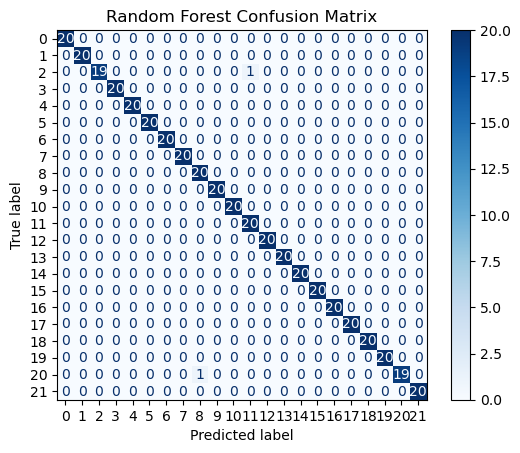

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues')

plt.title("Random Forest Confusion Matrix")

plt.savefig("random_forest_confusion_matrix.png",dpi=300,bbox_inches="tight")

plt.show()

In [67]:
N = float(input("Enter Nitrogen (N): "))
P = float(input("Enter Phosphorus (P): "))
K = float(input("Enter Potassium (K): "))
temperature = float(input("Enter Temperature (°C): "))
humidity = float(input("Enter Humidity (%): "))
ph = float(input("Enter pH: "))
rainfall = float(input("Enter Rainfall (mm): "))

sample = [[N, P, K, temperature, humidity, ph, rainfall]]

sample_scaled = scaler.transform(sample)

prediction = knn.predict(sample_scaled)

crop = le.inverse_transform(prediction)

print("\nRecommended Crop:", crop[0])

Enter Nitrogen (N):  85
Enter Phosphorus (P):  58
Enter Potassium (K):  41
Enter Temperature (°C):  26.5
Enter Humidity (%):  80
Enter pH:  6.7
Enter Rainfall (mm):  120



Recommended Crop: maize


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


> A custom prediction module was implemented to **allow users to enter soil nutrient values (N, P, K), environmental conditions (temperature, humidity, rainfall), and soil pH.**
> The trained KNN model processes these inputs and **recommends the most suitable crop.**
> This demonstrates the practical applicability of the crop recommendation system in real-world agricultural decision-making.

> **Conclusion**

> - This project successfully developed a Crop Recommendation System using supervised machine learning techniques to predict the most suitable crop based on soil nutrients and environmental conditions.
> - Three supervised learning algorithms—**Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest—were implemented and evaluated** using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. The comparison showed that **Random Forest achieved the highest performance,** with an accuracy of approximately 98–99%, outperforming Logistic Regression and KNN. This superior performance is due to Random Forest's ability to handle complex relationships, reduce overfitting through ensemble learning, and generalize well on unseen data.